In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.spatial.distance import cdist
import collections
import pickle
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [2]:
metadata_df = pd.read_csv('./metadata.csv', index_col='cord_uid')

c:\program files\python37\lib\site-packages\IPython\core\interactiveshell.py:3063: DtypeWarning: Columns (13,14) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [3]:
metadata_df

,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,mag_id,who_covidence_id,arxiv_id,pdf_json_files,pmc_json_files,url,s2_id
cord_uid,,,,,,,,,,,,,,,,,,
ug7v899j,d1aafb70c066a2068b02786f8929fd9c900897fb,PMC,Clinical features of culture-proven Mycoplasma...,10.1186/1471-2334-1-6,PMC35282,11472636.0,no-cc,OBJECTIVE: This retrospective chart review des...,2001-07-04,"Madani, Tariq A; Al-Ghamdi, Aisha A",BMC Infect Dis,NaN,NaN,NaN,document_parses/pdf_json/d1aafb70c066a2068b027...,document_parses/pmc_json/PMC35282.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN
02tnwd4m,6b0567729c2143a66d737eb0a2f63f2dce2e5a7d,PMC,Nitric oxide: a pro-inflammatory mediator in l...,10.1186/rr14,PMC59543,11667967.0,no-cc,Inflammatory diseases of the respiratory tract...,2000-08-15,"Vliet, Albert van der; Eiserich, Jason P; Cros...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/6b0567729c2143a66d737...,document_parses/pmc_json/PMC59543.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
ejv2xln0,06ced00a5fc04215949aa72528f2eeaae1d58927,PMC,Surfactant protein-D and pulmonary host defense,10.1186/rr19,PMC59549,11667972.0,no-cc,Surfactant protein-D (SP-D) participates in th...,2000-08-25,"Crouch, Erika C",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/06ced00a5fc04215949aa...,document_parses/pmc_json/PMC59549.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
2b73a28n,348055649b6b8cf2b9a376498df9bf41f7123605,PMC,Role of endothelin-1 in lung disease,10.1186/rr44,PMC59574,11686871.0,no-cc,Endothelin-1 (ET-1) is a 21 amino acid peptide...,2001-02-22,"Fagan, Karen A; McMurtry, Ivan F; Rodman, David M",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/348055649b6b8cf2b9a37...,document_parses/pmc_json/PMC59574.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
9785vg6d,5f48792a5fa08bed9f56016f4981ae2ca6031b32,PMC,Gene expression in epithelial cells in respons...,10.1186/rr61,PMC59580,11686888.0,no-cc,Respiratory syncytial virus (RSV) and pneumoni...,2001-05-11,"Domachowske, Joseph B; Bonville, Cynthia A; Ro...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/5f48792a5fa08bed9f560...,document_parses/pmc_json/PMC59580.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
l5zxic3y,2d3e143e2831835a7c039768d2cb101ba4506324,Medline; PMC,A Frail Health Care System for an Old Populati...,10.1093/gerona/glaa087,PMC7188183,32314784.0,no-cc,NaN,2020-04-21,"Volpato, Stefano; Landi, Francesco; Incalzi, R...",J Gerontol A Biol Sci Med Sci,NaN,NaN,NaN,document_parses/pdf_json/2d3e143e2831835a7c039...,document_parses/pmc_json/PMC7188183.xml.json,https://doi.org/10.1093/gerona/glaa087; https:...,216047223.0
3ysa4twk,e8d924391205ed4d2d320dba9f4f3f472fba8980,Medline; PMC,Risks of ACE Inhibitor and ARB Usage in COVID‐...,10.1002/cpt.1863,PMC7264499,32320478.0,no-cc,Concerns have been raised regarding the safety...,2020-05-10,"Sriram, Krishna; Insel, Paul A.",Clin Pharmacol Ther,NaN,NaN,NaN,document_parses/pdf_json/e8d924391205ed4d2d320...,document_parses/pmc_json/PMC7264499.xml.json,https://www.ncbi.nlm.nih.gov/pubmed/32320478/;...,216083471.0
xr067v2n,a94659ddedb5f2315276c5f527921fbfbd1bef20,Medline; PMC,"Distinguishing knowledge-sharing, knowledge-co...",10.1007/s11412-009-9069-5,PMC7088907,32214914.0,cc-by-nc,The study reported here sought to obtain the c...,2009-06-20,"van Aalst, Jan",Int J Comput Support Collab Learn,NaN,NaN,NaN,document_parses/pdf_json/a94659ddedb5f2315276c...,document_parses/pmc_json/PMC7088907.xml.json,https://www.ncbi.nlm.nih.gov/pubmed/32214914/;...,214679742.0


In [6]:
example_df = pd.read_csv('./How does temperature and humidity affect the transmission of 2019-nCoV.csv')

In [7]:
example_df

,Unnamed: 0,Date,Study,Study Link,Journal,Study Type,Factors,Influential,Excerpt,Measure of Evidence,Added on
0,0,2020-05-26,Containing the Spread of Coronavirus Disease 2...,https://doi.org/10.1101/2020.05.23.20111468,medrxiv,Ecological Regression,Temperature,Y,We found that high temperature mitigates the t...,countries: 70,05/31/2020
1,1,2020-05-26,Containing the Spread of Coronavirus Disease 2...,https://doi.org/10.1101/2020.05.23.20111468,medrxiv,Ecological Regression,Relative Humidity,Y,High relative humidity promotes COVID-19 trans...,countries: 70,05/31/2020
2,2,2020-05-25,COVID-19: Effects of weather conditions on the...,https://doi.org/10.1101/2020.05.24.20111963,medrxiv,Simulation,Temperature,Y,Our results suggest that high temperature and ...,-,05/31/2020
3,3,2020-05-25,COVID-19: Effects of weather conditions on the...,https://doi.org/10.1101/2020.05.24.20111963,medrxiv,Simulation,Humidity,Y,Our results suggest that high temperature and ...,-,05/31/2020
4,4,2020-05-24,The Modest Impact of Weather and Air Pollution...,https://doi.org/10.1101/2020.05.05.20092627,medrxiv,Ecological Regression,Temperature,Y,We found a robust effect of mean daily tempera...,locations: 3739,05/24/2020
...,...,...,...,...,...,...,...,...,...,...,...
62,62,2020-02-21,Molecular mechanism of evolution and human inf...,https://doi.org/10.1101/2020.02.17.952903,biorxiv,Basic Science,Temperature,Y,2019-nCoV will be less infectious with rising ...,-,04/08/2020
63,63,2020-02-18,Analysis of meteorological conditions and pred...,https://doi.org/10.1101/2020.02.13.20022715,medrxiv,Ecological Regression,Temperature,Y,"The humidity range is 50%-80%, of which about ...","cities: Wuhan, Guangzhou",04/15/2020
64,64,2020-02-18,Analysis of meteorological conditions and pred...,https://doi.org/10.1101/2020.02.13.20022715,medrxiv,Ecological Regression,Humidity,Y,"The humidity range is 50%-80%, of which about ...","cities: Wuhan, Guangzhou",04/15/2020
65,65,2020-02-17,The role of absolute humidity on transmission ...,https://doi.org/10.1101/2020.02.12.20022467,medrxiv,Ecological Regression,Temperature,N,Weather alone will not lead to a decrease in C...,-,04/15/2020


In [8]:
# find the example sha and uids for the example papers
example_shas = []
example_uids = []
for index, row in example_df.iterrows():
    study_title = row['Study']
    study_metadata = metadata_df[metadata_df['title'] == study_title]
    if len(study_metadata) != 0:
        sha = study_metadata.iloc[0]['sha']
        uid = study_metadata.iloc[0].name
        if str(sha) != 'nan':
            example_shas.append(sha)
            example_uids.append(uid)

In [9]:
example_uids

['vxy41zov',
 'vxy41zov',
 'tyhtdawb',
 'tyhtdawb',
 '3xw4qjoy',
 '11pcdnlw',
 'wr4r7jd8',
 'r1yjphnn',
 'r9yrr45q',
 'r9yrr45q',
 'q3abp9o7',
 'q3abp9o7',
 '147yc66p',
 'ekal5251',
 'g26to20g',
 'lmjaldcs',
 'lmjaldcs',
 'lmjaldcs',
 'lmjaldcs',
 'bnrmh1qs',
 '1p941spn',
 '1p941spn',
 'ycrrsr5c',
 '6anr4xdw',
 '6anr4xdw',
 '6anr4xdw',
 'vc2eheb6',
 'vc2eheb6',
 'u19e9j2w',
 '3svnvozz',
 '3svnvozz',
 'f53i4n02',
 'f53i4n02',
 'f53i4n02',
 'it0vccw3',
 'it0vccw3',
 'qz2joxys',
 'qz2joxys',
 'f4hj35dr',
 'f4hj35dr',
 'hicqy5sj',
 'zvngy7zz',
 'zvngy7zz']

In [10]:
unique_example_uids = set(example_uids)
len(unique_example_uids)

25

In [12]:
embeddings_df = pd.read_csv('./cord_19_embeddings_2020-06-09.csv', header=None, index_col=0)

In [13]:
available_uids = unique_example_uids.intersection(embeddings_df.index) # select example uids with an available embedding
example_embeddings_df = embeddings_df.loc[available_uids]

In [14]:
example_embeddings_df

,1,2,3,4,5,6,7,8,9,10,...,759,760,761,762,763,764,765,766,767,768
0,,,,,,,,,,,,,,,,,,,,,
vxy41zov,-3.355922,-6.525721,-1.067004,5.917986,-0.222711,-3.757181,3.041008,2.042803,0.582729,0.637698,...,-1.482825,2.145720,0.049413,-1.446993,-3.158589,-3.911877,4.067837,-0.245132,2.205867,-0.884997
qz2joxys,-5.520174,-7.226372,-0.394806,5.218612,1.818853,-3.392532,1.893002,-1.688817,1.756161,-2.188459,...,-0.784674,2.988649,-0.595812,-2.040640,-2.316293,-6.518475,2.911728,1.824538,-0.025863,3.147735
6anr4xdw,-4.691714,-7.104514,-3.342764,3.759823,0.905787,-5.367285,-0.689866,-2.662478,-1.125585,-0.409015,...,-0.149197,4.297982,-0.273927,-1.934015,-2.229969,-3.079901,3.769004,3.058187,-0.479943,3.808510
q3abp9o7,-2.230341,-6.126871,-1.365903,5.314121,0.510275,-5.927885,-0.191866,0.442595,-0.771622,1.872289,...,-1.829710,3.931727,1.686886,-3.343260,-1.386669,-3.700541,4.467555,2.636280,-2.358371,4.327785
f53i4n02,-3.937363,-6.372443,-1.811398,4.637398,0.964071,-5.160387,-0.041333,-2.816519,-1.433520,-0.194368,...,0.123645,3.775359,-1.514041,-1.967635,-2.660041,-3.082204,3.216224,2.927614,-1.174205,2.998173
ycrrsr5c,-3.177495,-6.502472,-0.989990,7.901762,1.060246,-6.131504,1.341731,1.346808,-0.183776,-1.061444,...,0.756959,4.516574,2.247248,-0.202155,-2.957935,-5.015463,1.919557,2.594363,-0.242878,-0.024909
zvngy7zz,-3.044027,-5.736067,-0.476197,6.569490,2.588360,-4.264059,3.327640,-1.081184,1.474251,-0.254700,...,-2.068252,1.884652,0.086034,-3.520173,-3.546034,-4.585379,2.835287,2.085707,0.066814,0.753262
r9yrr45q,-6.922812,-8.191954,-2.376089,8.085382,2.987336,-5.574221,4.644065,-2.975914,1.907547,-1.406794,...,-1.782094,1.464491,-0.611054,-0.449144,-1.110028,-4.027049,2.494863,-1.870053,0.696720,-0.410770
f4hj35dr,-2.593710,-3.416981,-0.876852,5.764600,1.007487,-3.159238,1.836467,0.719317,0.234497,-4.532489,...,0.353048,2.668141,-0.766035,-1.192543,-0.911440,-3.245960,4.492293,1.270075,-1.073007,0.228347


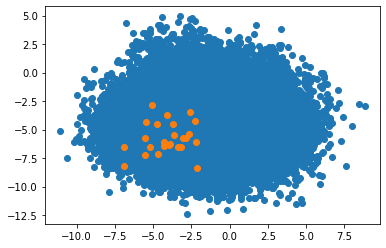

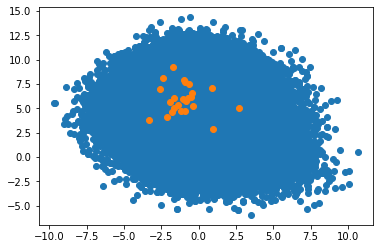

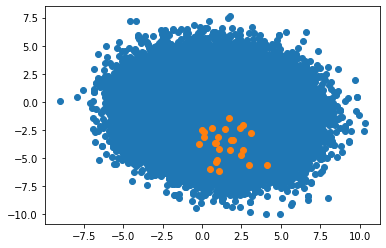

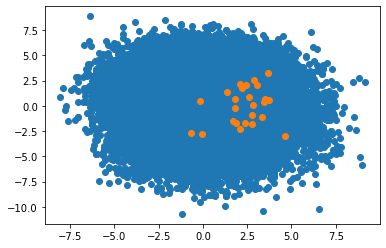

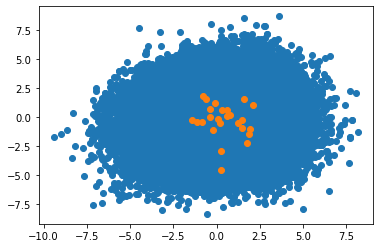

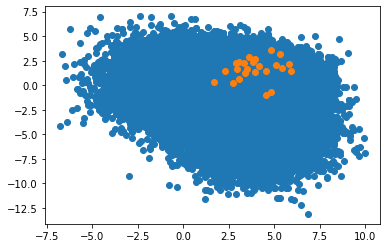

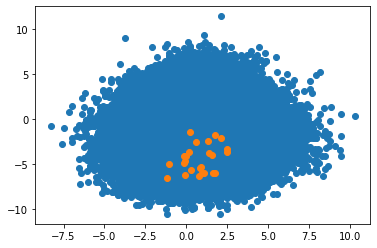

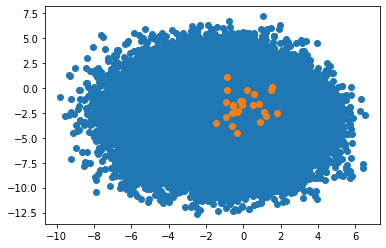

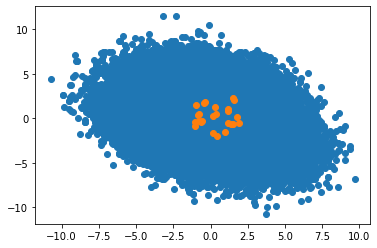

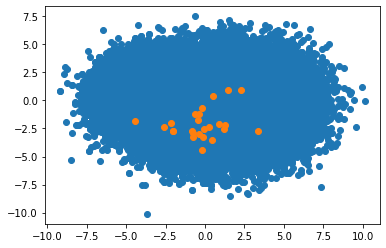

In [15]:
# first lets see some plots of the embeddings features for the examples vs the rest of the papers
for i in range(1, 21, 2):
    plt.scatter(embeddings_df[i], embeddings_df[i+1])
    plt.scatter(example_embeddings_df[i], example_embeddings_df[i+1])
    plt.show()

In [16]:
# First, lets get the population mean for each embedding feature
feature_pop_means = embeddings_df.mean(0)

In [17]:
# Now run the t-tests
t_stats, p_vals = stats.ttest_1samp(example_embeddings_df, feature_pop_means)

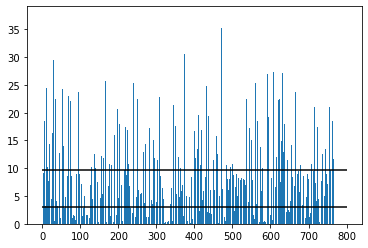

In [18]:
# here we show some visualizations of feature significance
plt.bar(range(len(p_vals)), -np.log(p_vals)) # we plot the negative log of the p-values for ease of visualization purposes
plt.hlines(-np.log(0.05), 0, 800) # line representing p-value of 0.05
plt.hlines(-np.log(0.05/len(p_vals)), 0, 800) # line representing a bonferroni adjusted p-value cutoff

In [19]:
# select the subset of informative features from original dataframe (selecting p-values < 0.05/len(p_vals))
informative_embeddings_df = embeddings_df.loc[:, p_vals < 0.05/len(p_vals)]

In [20]:
informative_embeddings_df

,1,3,6,7,11,12,14,15,20,21,...,746,747,754,755,756,759,762,764,767,768
0,,,,,,,,,,,,,,,,,,,,,
ug7v899j,-2.939984,-1.045903,-2.507413,1.735609,2.747691,-0.693098,-5.885725,-1.097485,-0.295981,1.770255,...,-3.480400,-3.017104,-2.760751,0.678841,9.059469,-0.741917,1.372890,-3.817415,-2.932384,0.305205
02tnwd4m,4.688466,1.228246,-0.406792,-2.296234,1.883721,-1.492986,-3.738881,0.892268,0.225149,1.099760,...,1.532649,0.148730,0.811119,0.015616,8.939779,-0.850256,-1.057281,0.276088,-5.686561,0.512474
ejv2xln0,0.559920,2.271945,-1.320622,-0.752549,4.365513,-5.431875,-4.260732,0.902808,0.162818,3.019039,...,3.868529,-2.309617,-2.696694,1.067947,10.098267,2.043988,4.812413,-2.131349,-2.847652,-1.536697
2b73a28n,2.352540,2.399774,1.867916,-3.466859,5.923308,-0.853207,-0.723905,-2.913522,-1.278515,-0.490068,...,2.599324,-2.169704,-3.626202,-0.079223,6.828236,0.109116,1.304383,-2.441383,-1.402024,3.922583
9785vg6d,-1.290922,1.557572,-4.537519,1.914945,7.448187,-1.623727,-5.975988,-0.036665,0.049160,0.596571,...,-1.706657,-3.369214,-4.300441,3.402898,8.272678,1.049299,1.695888,-3.247509,1.244299,-4.117685
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
l5zxic3y,-1.165249,0.100088,-1.598418,-2.995579,2.295629,0.933008,0.881210,-0.768004,0.813898,-1.914828,...,-1.427696,-3.131925,-6.513693,-2.513115,2.412514,-2.033003,1.341500,-2.326858,-0.946523,1.413297
3ysa4twk,0.210475,-2.877558,-3.856576,-1.656664,2.672227,-1.049902,-3.157624,0.349874,-1.263900,-0.380901,...,-2.828319,-1.301648,-4.650023,-3.758148,9.173846,-1.761774,0.180699,-3.518629,-2.560388,2.691125
xr067v2n,0.137031,-0.228683,0.326178,1.300470,-2.208520,-3.635073,-1.526997,0.288667,-3.563738,3.819357,...,-1.056146,0.904864,-1.490846,0.167533,5.056937,-0.402925,2.155870,-1.699792,-7.487648,-3.713327


In [21]:
clustering = KMeans(n_clusters=10, random_state=0).fit(informative_embeddings_df.values)

In [22]:
# get the cluster labels
labels = clustering.labels_

In [23]:
collections.Counter(labels)

Counter({8: 17245,
         4: 11108,
         6: 16363,
         5: 10880,
         3: 10663,
         0: 13272,
         2: 17838,
         9: 9857,
         1: 20177,
         7: 11391})

In [24]:
uid_cluster_map = dict(zip(informative_embeddings_df.index, labels)) # map the uids to the cluster labels

In [25]:
example_clusters = [uid_cluster_map[uid] for uid in example_embeddings_df.index] # find the cluster assigned to each of the example papers

In [26]:

example_clusters

[3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3]

In [27]:
for i in range(1, 11):
    print('cluster', i)
    cluster_ids = set([k for k, v in uid_cluster_map.items() if v == i])
    cluster_ids = cluster_ids.intersection(metadata_df.index)
    for ele in metadata_df.loc[cluster_ids, 'title']:
        if isinstance(ele, str):
            # use this rule to filter out non-relevant papers and focus on the coronavirus related content
            if ('corona' in ele.lower() or 'cov' in ele.lower()) and ('humid' in ele.lower() or 'temperature' in ele.lower()):
                print('\t', ele)
    print('#'*25)

cluster 1
	 Body temperature correlates with mortality in COVID-19 patients
	 Murine coronavirus temperature sensitive mutants.
	 Temperature Monitoring with an Implantable Loop Recorder in a Patient with Presumed COVID-19
	 Is temperature reducing the transmission of COVID-19 ?
#########################
cluster 2
	 Responding to the COVID-19 outbreak in Singapore: Staff Protection and Staff Temperature and Sickness Surveillance Systems
	 Understanding the binding affinity of noscapines with protease of SARS-CoV-2 for COVID-19 using MD simulations at different temperatures
	 Responding to the COVID-19 outbreak in Singapore: Staff Protection and Staff Temperature and Sickness Surveillance Systems
	 Inactivating porcine coronavirus before nuclei acid isolation with the temperature higher than 56 °C damages its genome integrity seriously
	 An experimental study of the survival of turkey coronavirus at room temperature and +4°C
	 SARS-CoV-2 infection: the environmental endurance of the vir

	 Induction of demyelination by a temperature-sensitive mutant of the coronavirus MHV-A59 is associated with restriction of viral replication in the brain.
	 [Bovine coronavirus reproduction in the continuous cell cultures at a temperature of 34 degrees C].
	 A single amino acid mutation in the spike protein of coronavirus infectious bronchitis virus hampers its maturation and incorporation into virions at the nonpermissive temperature
	 Characterization of a temperature sensitive feline infectious peritonitis coronavirus
	 Pathogenic murine coronaviruses III. Biological and biochemical characterization of temperature sensitive mutants of JHMV
	 Altered proteolytic processing of the polymerase polyprotein in RNA(-) temperature sensitive mutants of murine coronavirus.
	 Temperature-sensitive mutants and revertants in the coronavirus nonstructural protein 5 protease (3CLpro) define residues involved in long-distance communication and regulation of protease activity.
	 Competitive Fitness